In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('./data/loan.csv', sep = ',')

C:\Users\human3_03\AppData\Local\Temp\ipykernel_7952\3781110496.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/loan.csv', sep = ',')


In [3]:
df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,5550,5550,5550.0,36 months,15.02,192.45,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,2000,2000,2000.0,36 months,17.97,72.28,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,6000,6000,6000.0,36 months,13.56,203.79,C,C1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,6000,6000,6000.0,36 months,14.47,206.44,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(2260668, 145)

In [5]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [6]:
df.tail(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260663,NaN,NaN,12000,12000,12000.0,60 months,14.08,279.72,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260664,NaN,NaN,12000,12000,12000.0,60 months,25.82,358.01,E,E4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260665,NaN,NaN,10000,10000,10000.0,36 months,11.99,332.10,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260666,NaN,NaN,12000,12000,12000.0,60 months,21.45,327.69,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260667,NaN,NaN,16550,16550,16550.0,60 months,21.45,451.94,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# 필요한 컬럼만 가져오기
df2 = df[['loan_amnt','loan_status','grade','int_rate', 'term']]

In [8]:
df2.head(5)

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months


In [9]:
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [10]:
df2['grade'].unique()

array(['C', 'D', 'B', 'A', 'E', 'F', 'G'], dtype=object)

In [11]:
df2['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [12]:
df2.shape

(2260668, 5)

In [13]:
# nan 제거하기  # how = any --> nan이 있는 그 행은 모두 삭제 / how = all은 행 전체에 nan이 있는 경우에만 행 삭제. 그렇지 않은 삭제 안함
df2 = df2.dropna(how = 'any')
df2.shape

(2260668, 5)

# 30개월/60개월 두 가지 대출 상품을 운영

# 문제1) '36개월 대출'과 '60개월 대출'의 대출 총액 계산

In [14]:
df_term_la = df[['loan_amnt', 'term']]
df_term_la

,loan_amnt,term
0,2500,36 months
1,30000,60 months
2,5000,36 months
3,4000,36 months
4,30000,60 months
...,...,...
2260663,12000,60 months
2260664,12000,60 months
2260665,10000,36 months
2260666,12000,60 months


In [15]:
df_3660 = df_term_la.loc[(df['term'] == ' 36 months') | (df_term_la['term'] == ' 60 months'), :]
df_3660

,loan_amnt,term
0,2500,36 months
1,30000,60 months
2,5000,36 months
3,4000,36 months
4,30000,60 months
...,...,...
2260663,12000,60 months
2260664,12000,60 months
2260665,10000,36 months
2260666,12000,60 months


In [16]:
df_3660['loan_amnt'].sum()

np.int64(34016115925)

# 강사님 풀이

In [55]:
# 결과를 저장할 딕셔너리 생성
term_to_loan_amnt_dict = {}
# term 컬럼의 교유값 추출
uniq_terms = df2['term'].unique()

In [56]:
# 각 대출기간(term)에 대해 반복 계산
# 해당 행들의 loan_amnt(대출금액) 컬럼 합계 계산
for term in uniq_terms:
    # df2.loc[df2['term'] 값이 uniq_term의 term과 같으면, loan_amnt의 열을 갖고 와서 sum을 수행
    loan_amnt_sum = df2.loc[df2['term'] == term, 'loan_amnt'].sum()
    # 계산된 합계를 딕셔너리에 저장
    term_to_loan_amnt_dict[term] = loan_amnt_sum

<function matplotlib.pyplot.show(close=None, block=None)>

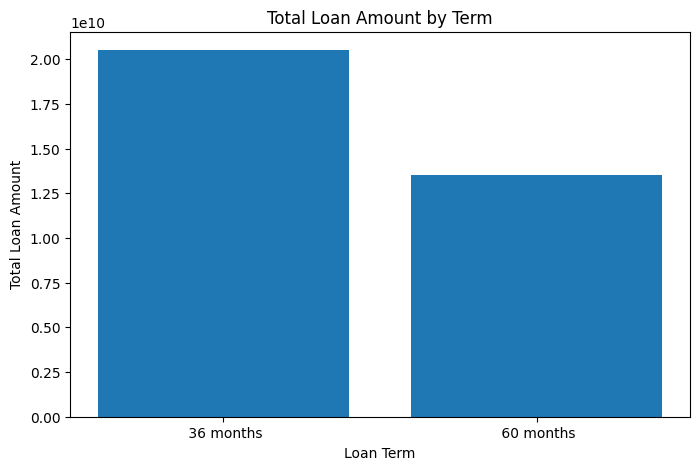

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    term_to_loan_amnt_dict.keys(),
    term_to_loan_amnt_dict.values()
)

plt.title('Total Loan Amount by Term')
plt.xlabel('Loan Term')
plt.ylabel('Total Loan Amount')

plt.show

# 문제2) 각 대출 상태(불량/우량)에 따른 대출 등급 분포 파악

In [21]:
df_ls_grade = df[['loan_status', 'grade']]
df_ls_grade

,loan_status,grade
0,Current,C
1,Current,D
2,Current,D
3,Current,D
4,Current,C
...,...,...
2260663,Current,C
2260664,Fully Paid,E
2260665,Current,B
2260666,Current,D


In [23]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [30]:
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

# 강사님 풀이

In [35]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months


In [36]:
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [43]:
# Loan_status 고유값 추출
total_status_category = df2['loan_status'].unique()

# 불량등급만 모으기 (인덱스로 정의)
bad_status_category = total_status_category[[3,4,5,6,8]]

In [44]:
bad_status_category

array(['In Grace Period', 'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [45]:
# Loan_status가 bae_status에 속하면 True, 아니면 False 표시
df2['bad_loan_status'] = df2['loan_status'].isin(bad_status_category)
df2.head()                                                

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,2500,Current,C,13.56,36 months,False
1,30000,Current,D,18.94,60 months,False
2,5000,Current,D,17.97,36 months,False
3,4000,Current,D,18.94,36 months,False
4,30000,Current,C,16.14,60 months,False


In [46]:
# bad_loan_status의 값이 true인 행의 grade 값에 대한 분포 확인
# --> 불량 대출 행만 선택해서 해당 grade의 빈도수 계산
bad_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == True, 'grade'].value_counts()

In [48]:
bad_loan_status_to_grades

grade
C    87940
D    62440
B    54000
E    36655
A    14711
F    14702
G     4688
Name: count, dtype: int64

In [49]:
# 등급순 정렬
bad_loan_status_to_grades.sort_index(ascending=True)

grade
A    14711
B    54000
C    87940
D    62440
E    36655
F    14702
G     4688
Name: count, dtype: int64

In [50]:
# 우량 등급 분포 확인
good_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == False, 'grade'].value_counts()
good_loan_status_to_grades

grade
B    609557
C    562113
A    418316
D    261984
E     98984
F     27098
G      7480
Name: count, dtype: int64

In [51]:
# 등급순 정렬
good_loan_status_to_grades.sort_index()

grade
A    418316
B    609557
C    562113
D    261984
E     98984
F     27098
G      7480
Name: count, dtype: int64

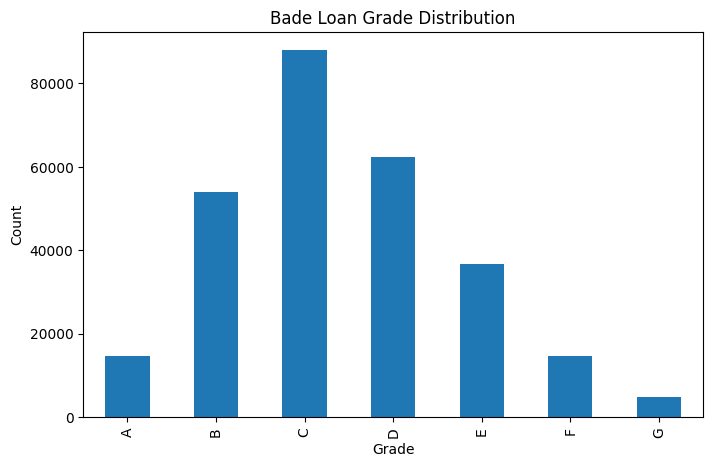

In [58]:
# 불량 대출 등급 분포
plt.figure(figsize=(8,5))
bad_loan_status_to_grades.sort_index().plot(
    kind='bar'
)

plt.title('Bade Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()


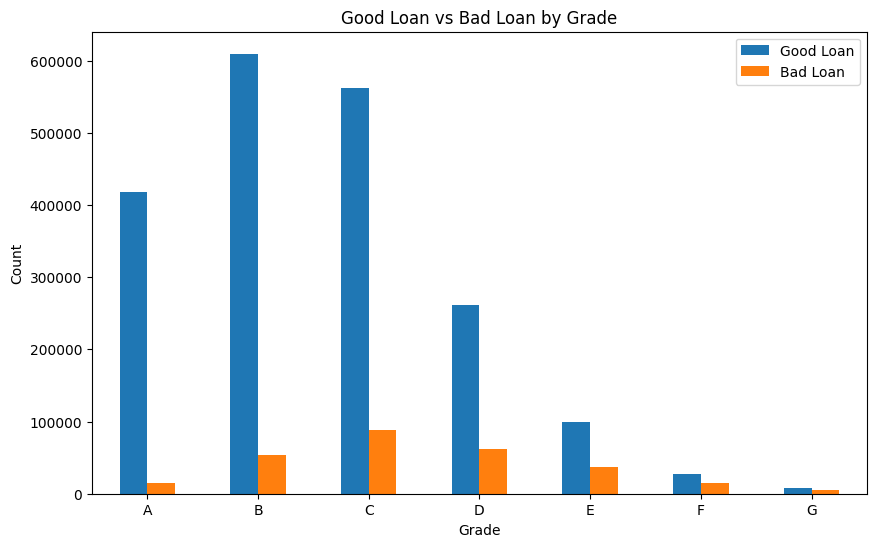

In [59]:
good_grade_counts = good_loan_status_to_grades.sort_index()
bad_grade_counts = bad_loan_status_to_grades.sort_index()

# 두 series를 하나의 dataframe으로 결함
compare_df = pd.concat(
    [good_grade_counts, bad_grade_counts],
    axis=1
)

# 컬럼명 지정
compare_df.columns = ['Good Loan', 'Bad Loan']

# 결측값이 있으면 0으로 대체
compare_df = compare_df.fillna(0)

#시각화
compare_df.plot(
    kind = 'bar',
    figsize=(10,6)
)

plt.title('Good Loan vs Bad Loan by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()




In [54]:
grade_status = pd.crosstab(
    df2['grade'],
    df2['bad_loan_status'],
    normalize='index'
)

grade_status

bad_loan_status,False,True
grade,,
A,0.966028,0.033972
B,0.918620,0.081380
C,0.864719,0.135281
D,0.807536,0.192464
E,0.729761,0.270239
F,0.648278,0.351722
G,0.614727,0.385273


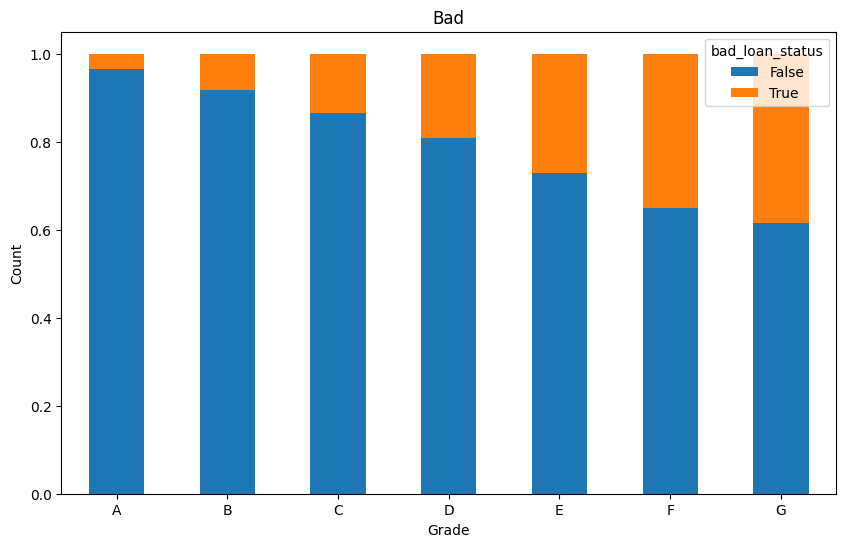

In [60]:
grade_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Bad')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()


# 문제3) 대출 총액과 대출 이자율 간의 상관관계 파악

In [24]:
df_lm_ir = df[['loan_amnt', 'int_rate']]
df_lm_ir

,loan_amnt,int_rate
0,2500,13.56
1,30000,18.94
2,5000,17.97
3,4000,18.94
4,30000,16.14
...,...,...
2260663,12000,14.08
2260664,12000,25.82
2260665,10000,11.99
2260666,12000,21.45


In [25]:
df_lm_ir['loan_amnt'].corr(df_lm_ir['int_rate'])

np.float64(0.09808333533023365)

In [26]:
df_lm_ir.corr()

,loan_amnt,int_rate
loan_amnt,1.000000,0.098083
int_rate,0.098083,1.000000


# 강사님 풀이

In [61]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,2500,Current,C,13.56,36 months,False
1,30000,Current,D,18.94,60 months,False
2,5000,Current,D,17.97,36 months,False
3,4000,Current,D,18.94,36 months,False
4,30000,Current,C,16.14,60 months,False


In [62]:
df2['loan_amnt'].corr(df2['int_rate'])

np.float64(0.09808333533023365)

+1 : 완벽한 양의 상관관계
0 : 관계 없음
-1 : 완벽한 음의 상관관계

0.0 ~ 0.1 : 거의 없음
0.1 ~ 0.3 : 약한 상관관계
0.3 ~ 0.5 : 보통 상관관계
0.5 ~ 0.7 : 강한 상관관계
0.7 ~ 1.0 : 매우 강한 상관관계

# 문제4) 결과를 csv 파일로 저장하기

In [27]:
data = {"sum_la" : [df_3660['loan_amnt'].sum()],
       "df_lm_if" : [df_lm_ir['loan_amnt'].corr(df_lm_ir['int_rate'])]}

In [28]:
df_l= pd.DataFrame(data, columns=['sum_la', 'df_lm_if'],
                  index=[1,2,3])

In [29]:
df_l.to_csv('./data/resultP.csv')

# 강사님 풀이

In [64]:
bad_loan_status_to_grades

grade
C    87940
D    62440
B    54000
E    36655
A    14711
F    14702
G     4688
Name: count, dtype: int64

In [65]:
bad_loan_status_to_grades.sort_index().to_csv('./data/bad_loan_status', sep=',')